PETROL CONSUMPTION AND ANALYSIS OF ETHANOL BLENDING

In [1]:
import sys
!"{sys.executable}" -m pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

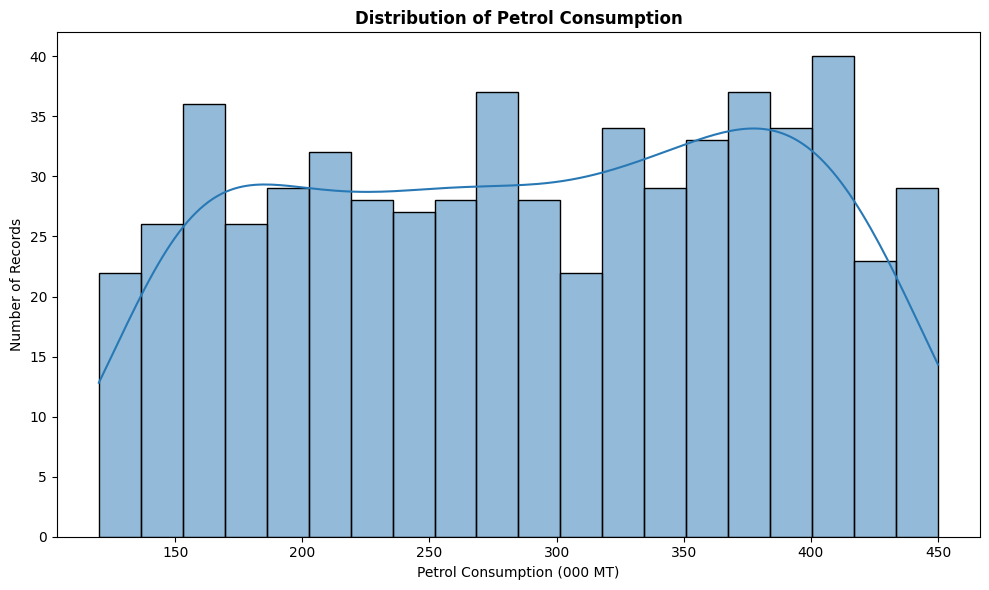

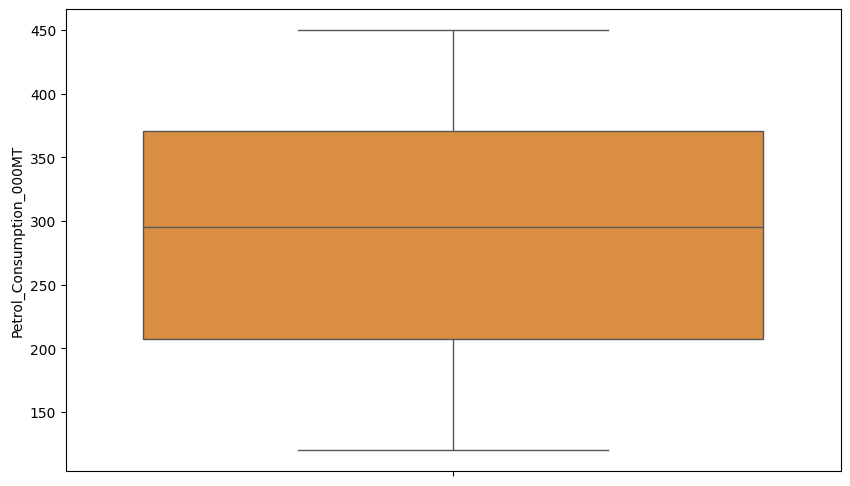

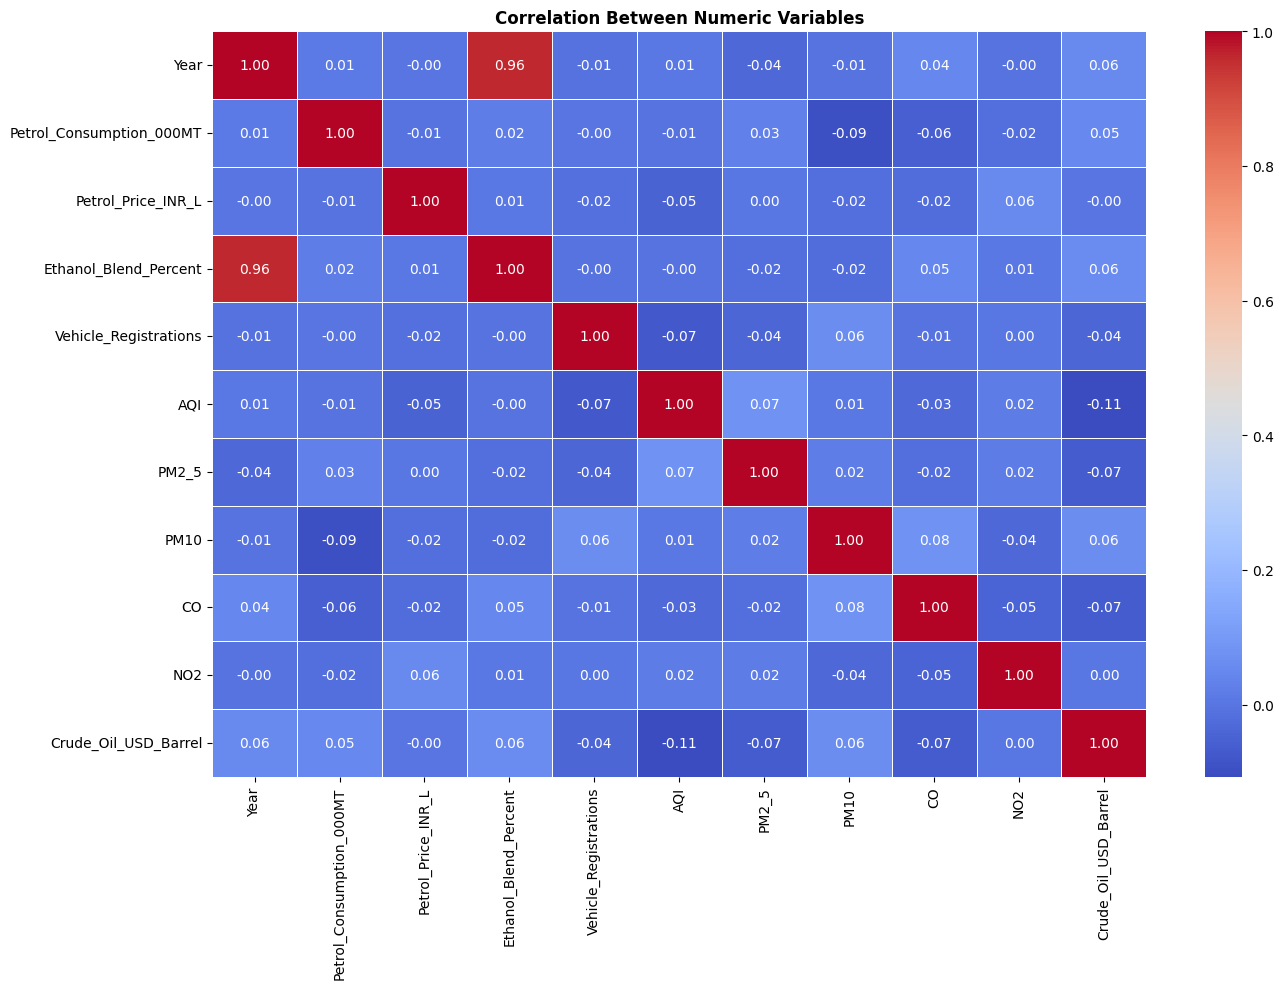

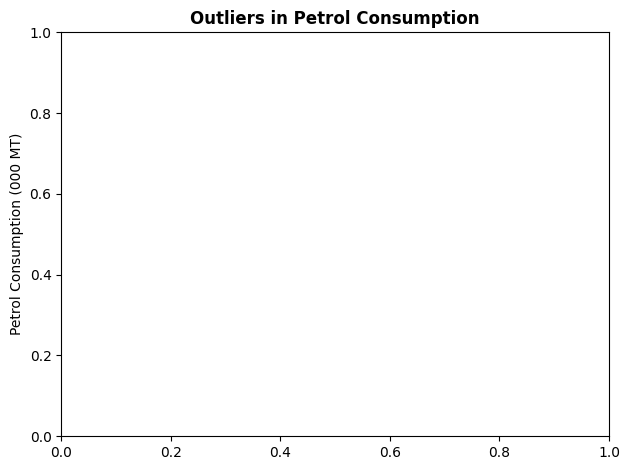

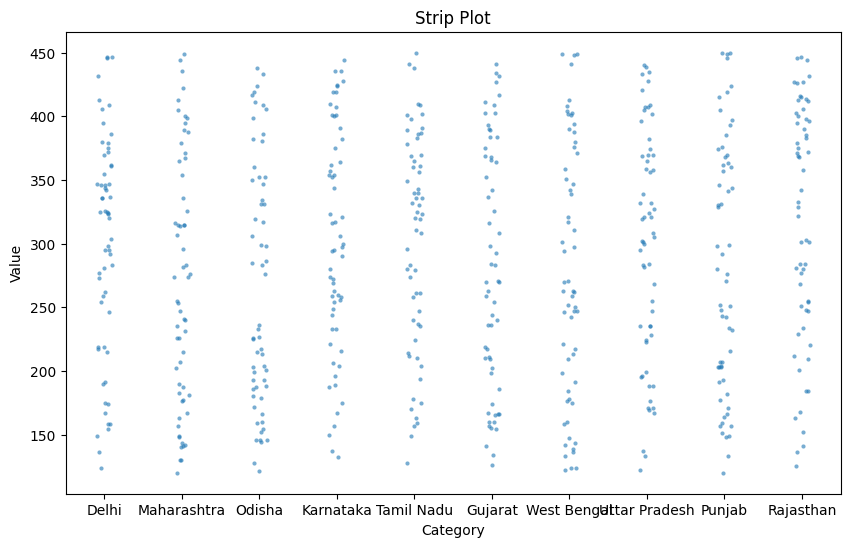

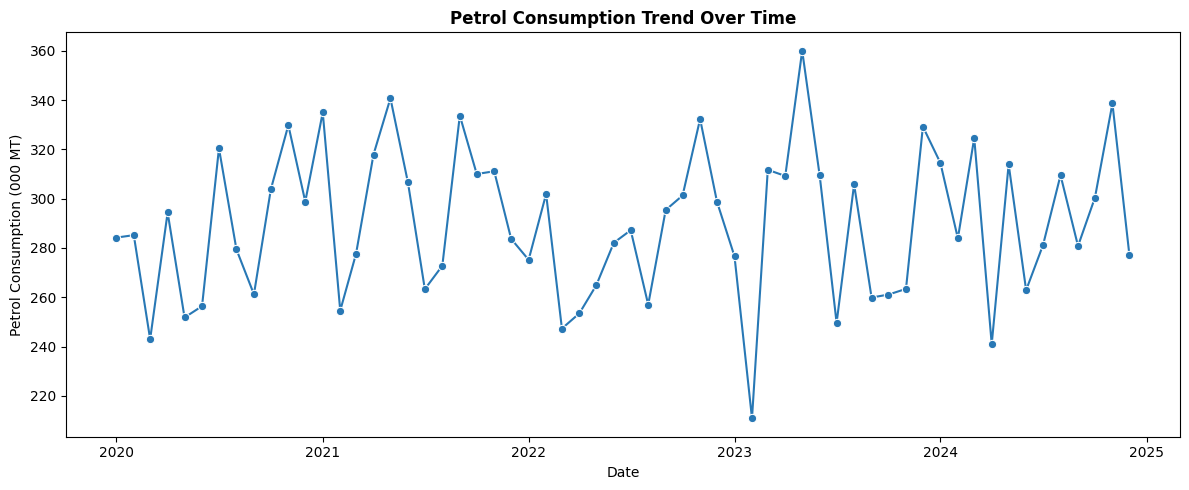

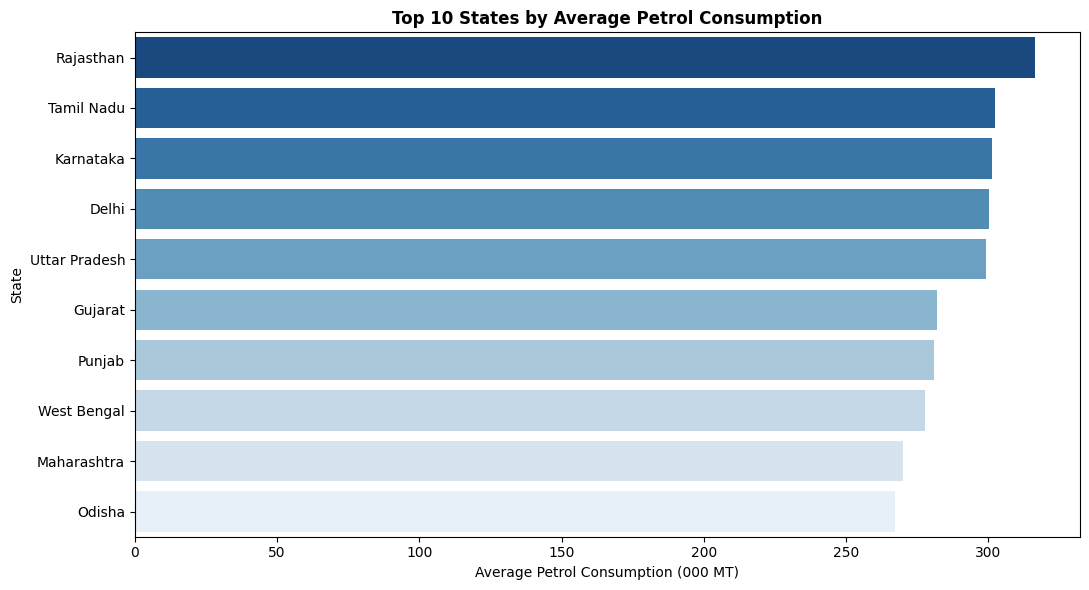

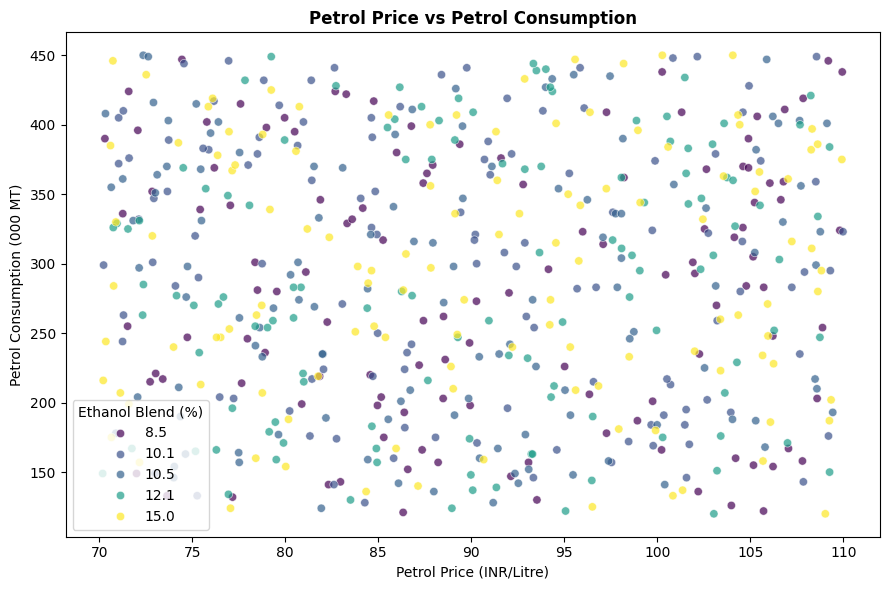

In [3]:
df = pd.read_excel(
    r"C:\Users\SWAGATIKA\Documents\E20_Petrol_EDA_Dataset_600_Rows.xlsx",
    engine="openpyxl"
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Distribution of Petrol Consumption - Histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Petrol_Consumption_000MT",
    bins=20,
    kde=True,
    color="#2878B5"
)

plt.title("Distribution of Petrol Consumption", weight="bold")
plt.xlabel("Petrol Consumption (000 MT)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

# 2. Outliers in Petrol Consumption - Box Plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    y="Petrol_Consumption_000MT",
    color="#F28E2B"
)

# 3. Correlation Between Numeric Variables - Heatmap
numeric_data = df.select_dtypes(include="number")

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Variables", weight="bold")
plt.tight_layout()
plt.show()

plt.title("Outliers in Petrol Consumption", weight="bold")
plt.ylabel("Petrol Consumption (000 MT)")
plt.tight_layout()
plt.show()

# 4.strip plot to show consumption of petrol_000MT in each state

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df,
    x="State",          # replace with your category column name
    y="Petrol_Consumption_000MT",     # replace with your numeric column name
    jitter=True,
    size=3,
    alpha=0.6
)

plt.title("Strip Plot")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()

# 5.Petrol-consumption trend over time
df["Date"] = pd.to_datetime(df["Date"])

monthly_data = (
    df.groupby("Date")["Petrol_Consumption_000MT"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_data,
    x="Date",
    y="Petrol_Consumption_000MT",
    color="#2878B5",
    marker="o"
)

plt.title("Petrol Consumption Trend Over Time", weight="bold")
plt.xlabel("Date")
plt.ylabel("Petrol Consumption (000 MT)")
plt.tight_layout()
plt.show()

# 6. Average petrol consumption by top 10 states
state_avg = (
    df.groupby("State")["Petrol_Consumption_000MT"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))
sns.barplot(
    x=state_avg.values,
    y=state_avg.index,
    hue=state_avg.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 States by Average Petrol Consumption", weight="bold")
plt.xlabel("Average Petrol Consumption (000 MT)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# 7.petrol price vs consumption
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Petrol_Price_INR_L",
    y="Petrol_Consumption_000MT",
    hue="Ethanol_Blend_Percent",
    palette="viridis",
    alpha=0.7
)

plt.title("Petrol Price vs Petrol Consumption", weight="bold")
plt.xlabel("Petrol Price (INR/Litre)")
plt.ylabel("Petrol Consumption (000 MT)")
plt.legend(title="Ethanol Blend (%)")
plt.tight_layout()
plt.show()

# SUMMARY

- The dataset contains 600 records related to petrol consumption, petrol prices, ethanol blending, vehicle registrations, and air-quality indicators.
- Ethanol blend percentages range from 8.5% to 15%, with an average of 11.24%.
- Petrol consumption differs across states and over time.
- The visualizations help identify relationships among petrol consumption, price, vehicle registrations, ethanol blending, and environmental indicators.

## Conclusion

This project analyzed petrol consumption and ethanol blending using 600 records. The dataset includes petrol consumption, petrol prices, ethanol blend percentages, vehicle registrations, and air-quality indicators.

The analysis showed that petrol consumption varies across states and time. Petrol price, vehicle registrations, ethanol blending, and environmental variables may be related to petrol consumption, as explored through the correlation heatmap, scatter plots, pair plot, and strip plot.

The ethanol blend percentage in this dataset ranges from 8.5% to 15%, so the analysis represents petrol and ethanol blending rather than E20 fuel specifically. Further analysis with 20% ethanol-blend data would be needed for a dedicated E20 study.